In [1]:
import os
import sys
import glob
import awkward as ak
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import uproot
import math
import re
import pandas as pd

In [2]:
arr = np.load('/standard/ldmxuva/EaT_bdt/bdt_3e13/bkg_scores_merged.npz')
bkgd_scores = arr['scores']
event_files = arr['filenames']
event_indices = arr['event_indices']

In [3]:
bkgd_combined_scores_array = np.column_stack((bkgd_scores, event_files, event_indices))

In [4]:
print(bkgd_combined_scores_array[0])

['1.7717568e-05'
 'enriched_nuclear_MaxEvents_5000000_skim_True_run_51020.root' '24']


In [5]:
#fighting fire with fire
df = pd.DataFrame(bkgd_combined_scores_array)
df_new = pd.DataFrame(columns=['score', 'file', 'event_index'])

# 1) Convert first and last columns to float
df_new['score'] = (df.iloc[:, 0]).astype(float)
df_new['event_index'] = (df.iloc[:, 2]).astype(float)

# 2) Extract run number, then drop the filename column
df_new['file'] = (df.iloc[:, 1]).str.extract(r'_run_(\d+)\.root$').astype(int)
#df = df.drop(columns='filename')

In [6]:
bdt_bkgd_arr = df_new.to_numpy()
print(len(bdt_bkgd_arr[:,0]))

7405314


In [7]:
background_inf_paths = glob.glob(os.path.join('/standard/ldmxuva/gnn_files/note_stuff/eat_equiv_eot_results/', "bk*"))

In [8]:
#now we can stack the arrays from our background
bkgd_arr_list = []
for file in background_inf_paths:
    arr = (np.load(file))['inference_info']
    bkgd_arr_list.append(arr)

In [9]:
gnn_bkgd_arr = np.vstack(bkgd_arr_list)

In [10]:
#lets quickly check for any different file entries:
#len(set(bdt_bkgd_arr[:,1]) - set(gnn_bkgd_arr[:,-1]))
extra_files = set(bdt_bkgd_arr[:,1]) - set(gnn_bkgd_arr[:,-1])

mask = ~np.isin(bdt_bkgd_arr[:, 2], list(extra_files))
bdt_bkgd_filtered = bdt_bkgd_arr[mask]

In [11]:
len(bdt_bkgd_filtered[:,0])

7390746

In [12]:
#bdt stuff

bdt_m100_scores = ((np.load('/standard/ldmxuva/EaT_bdt/bdt_3e13/sig_scores_mA_0100.npz'))['scores'])
bdt_m050_scores = ((np.load('/standard/ldmxuva/EaT_bdt/bdt_3e13/sig_scores_mA_0050.npz'))['scores'])
bdt_m010_scores = ((np.load('/standard/ldmxuva/EaT_bdt/bdt_3e13/sig_scores_mA_0010.npz'))['scores'])
bdt_m005_scores = ((np.load('/standard/ldmxuva/EaT_bdt/bdt_3e13/sig_scores_mA_0005.npz'))['scores'])


bdt_m010_roc_arr = np.concatenate((bdt_bkgd_filtered[:,0], bdt_m010_scores))
bdt_m010_roc_arr_true = np.concatenate((np.zeros_like(bdt_bkgd_filtered[:,0]), np.ones_like(bdt_m010_scores)))

bdt_m050_roc_arr = np.concatenate((bdt_bkgd_filtered[:,0], bdt_m050_scores))
bdt_m050_roc_arr_true = np.concatenate((np.zeros_like(bdt_bkgd_filtered[:,0]), np.ones_like(bdt_m050_scores)))

bdt_m005_roc_arr = np.concatenate((bdt_bkgd_filtered[:,0], bdt_m005_scores))
bdt_m005_roc_arr_true = np.concatenate((np.zeros_like(bdt_bkgd_filtered[:,0]), np.ones_like(bdt_m005_scores)))

bdt_m100_roc_arr = np.concatenate((bdt_bkgd_filtered[:,0], bdt_m100_scores))
bdt_m100_roc_arr_true = np.concatenate((np.zeros_like(bdt_bkgd_filtered[:,0]), np.ones_like(bdt_m100_scores)))

In [13]:
fpr100_bdt, tpr100_bdt, thresholds100_bdt = roc_curve(bdt_m100_roc_arr_true, bdt_m100_roc_arr)
roc_auc_100_bdt = auc(fpr100_bdt, tpr100_bdt)

fpr005_bdt, tpr005_bdt, thresholds005_bdt = roc_curve(bdt_m005_roc_arr_true, bdt_m005_roc_arr)
roc_auc_005_bdt = auc(fpr005_bdt, tpr005_bdt)

fpr010_bdt, tpr010_bdt, thresholds010_bdt = roc_curve(bdt_m010_roc_arr_true, bdt_m010_roc_arr)
roc_auc_010_bdt = auc(fpr010_bdt, tpr010_bdt)

fpr050_bdt, tpr050_bdt, thresholds050_bdt = roc_curve(bdt_m050_roc_arr_true, bdt_m050_roc_arr)
roc_auc_050_bdt = auc(fpr050_bdt, tpr050_bdt)

Text(0.5, 1.0, 'BDT ROC All Masses')

/home/wer2ct/.local/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/wer2ct/.local/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


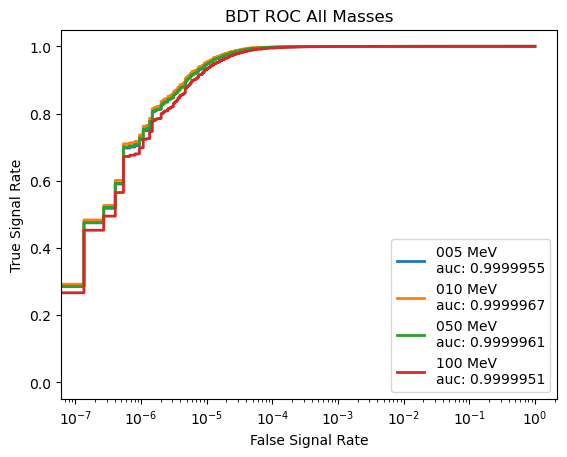

In [14]:
plt.plot(fpr005_bdt, tpr005_bdt, label = f'005 MeV\nauc: {roc_auc_005_bdt:.7f}', lw = 2, color = 'C0')
plt.plot(fpr010_bdt, tpr010_bdt, label = f'010 MeV\nauc: {roc_auc_010_bdt:.7f}', lw = 2, color = 'C1')
plt.plot(fpr050_bdt, tpr050_bdt, label = f'050 MeV\nauc: {roc_auc_050_bdt:.7f}', lw = 2, color = 'C2')
plt.plot(fpr100_bdt, tpr100_bdt, label = f'100 MeV\nauc: {roc_auc_100_bdt:.7f}', lw = 2, color = 'C3')

plt.legend()
plt.xscale('log')
plt.xlabel('False Signal Rate')
plt.ylabel('True Signal Rate')
plt.title('BDT ROC All Masses')

In [13]:
#now same with the gnn
background_inf_paths = glob.glob(os.path.join('/standard/ldmxuva/gnn_files/note_stuff/eat_equiv_eot_results/', "bk*"))
signal_inf_paths = glob.glob(os.path.join('/standard/ldmxuva/gnn_files/note_stuff/eat_equiv_eot_results/signal/', 'v*'))
#load in each of the signal mass point arrays
m010_inference_arr = (np.load(signal_inf_paths[0]))['inference_info']
m050_inference_arr = (np.load(signal_inf_paths[1]))['inference_info']
m005_inference_arr = (np.load(signal_inf_paths[2]))['inference_info']
m100_inference_arr = (np.load(signal_inf_paths[3]))['inference_info']
print(len(m100_inference_arr))

#now we can stack the arrays from our background
bkgd_arr_list = []
for file in background_inf_paths:
    arr = (np.load(file))['inference_info']
    bkgd_arr_list.append(arr)

27961


In [14]:
#Create a stacked array
bkgd_arr = np.vstack(bkgd_arr_list)
print(len(bkgd_arr[:,0]))
#Now create stacks for each roc curve
m010_roc_arr = np.vstack((m010_inference_arr, bkgd_arr))
m050_roc_arr = np.vstack((m050_inference_arr, bkgd_arr))
m005_roc_arr = np.vstack((m005_inference_arr, bkgd_arr))
m100_roc_arr = np.vstack((m100_inference_arr, bkgd_arr))

7332998


In [17]:
#We can now create ROC curves (dynamic score, static, truth)
fpr100_d, tpr100_d, thresholds100_d = roc_curve(m100_roc_arr[:,2], m100_roc_arr[:,0])
roc_auc_100_d = auc(fpr100_d, tpr100_d)

fpr005_d, tpr005_d, thresholds005_d = roc_curve(m005_roc_arr[:,2], m005_roc_arr[:,0])
roc_auc_005_d = auc(fpr005_d, tpr005_d)

fpr010_d, tpr010_d, thresholds010_d = roc_curve(m010_roc_arr[:,2], m010_roc_arr[:,0])
roc_auc_010_d = auc(fpr010_d, tpr010_d)

fpr050_d, tpr050_d, thresholds050_d = roc_curve(m050_roc_arr[:,2], m050_roc_arr[:,0])
roc_auc_050_d = auc(fpr050_d, tpr050_d)

In [ ]:
plt.plot(fpr100_d, tpr100_d, label = f'dynamic model\nauc: {roc_auc_100_d:.7f}', lw = 2, color = 3)
plt.plot(fpr050_d, tpr050_d, label = f'dynamic model\nauc: {roc_auc_050_d:.7f}', lw = 2, color = 2)
plt.plot(fpr010_d, tpr010_d, label = f'dynamic model\nauc: {roc_auc_010_d:.7f}', lw = 2, color = 1)
plt.plot(fpr005_d, tpr005_d, label = f'dynamic model\nauc: {roc_auc_005_d:.7f}', lw = 2, color = 0)
plt.legend()
plt.xscale('log')
plt.xlabel('False Signal Rate')
plt.ylabel('True Signal Rate')
plt.title('Deeper ROC Curve Comparison (Static, Dynamic), 100 MeV Signal')

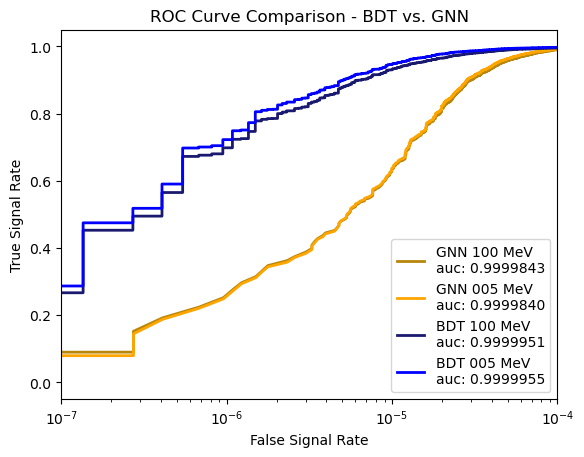

In [26]:
#We can plot a direct comparison plot. 
plt.plot(fpr100_d, tpr100_d, label = f'GNN 100 MeV\nauc: {roc_auc_100_d:.7f}', lw = 2, color = 'darkgoldenrod')
plt.plot(fpr005_d, tpr005_d, label = f'GNN 005 MeV\nauc: {roc_auc_005_d:.7f}', lw = 2, color = 'orange')
plt.plot(fpr100_bdt, tpr100_bdt, label = f'BDT 100 MeV\nauc: {roc_auc_100_bdt:.7f}', lw = 2, color = 'midnightblue')
plt.plot(fpr005_bdt, tpr005_bdt, label = f'BDT 005 MeV\nauc: {roc_auc_005_bdt:.7f}', lw = 2, color = 'blue')
plt.legend(loc = 'lower right')
plt.xlim((1e-7,1e-4))
#plt.ylim((0.9,1))
plt.xscale('log')
plt.xlabel('False Signal Rate')
plt.ylabel('True Signal Rate')
plt.title('ROC Curve Comparison - BDT vs. GNN')
plt.savefig("comparison_roc_3e13.png")

In [15]:
bdt_m100_signal_scores = bdt_m100_scores
gnn_m100_signal_scores = m100_inference_arr[:,0]
bdt_bkgd_scores = bdt_bkgd_filtered[:,0]
gnn_bkgd_scores = bkgd_arr[:,0]

In [35]:
print(np.max(bdt_bkgd_scores))
sig_eff_bdt = len(bdt_m100_signal_scores[bdt_m100_signal_scores > np.max(bdt_bkgd_scores)]) / len(bdt_m100_signal_scores)
s_effs_bdt = []
b_rates_bdt = []
for i in range(1,500):
    disc = 1 - (0.01 / (i*10))
    sig_eff_bdt = len(bdt_m100_signal_scores[bdt_m100_signal_scores > disc]) / len(bdt_m100_signal_scores)
    s_effs_bdt.append(sig_eff_bdt)
    background_rate = len(bdt_bkgd_scores[bdt_bkgd_scores > disc]) #/ len(bdt_bkgd_scores)
    b_rates_bdt.append(background_rate)

0.9999938


In [36]:
#print(sig_eff_bdt)
len(bdt_m100_signal_scores[bdt_m100_signal_scores > np.max(bdt_bkgd_scores)]) / len(bdt_m100_signal_scores)

0.26651187712091445

(0.0, 15.0)

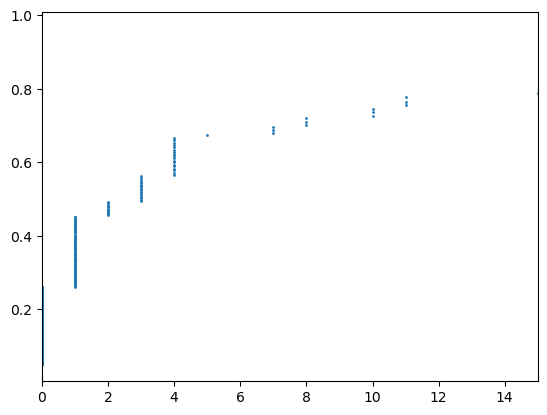

In [38]:
plt.scatter(b_rates_bdt, s_effs_bdt, s = 1)
plt.xlim((0,15))

In [42]:
comb_arr = np.column_stack((np.array(b_rates_bdt), np.array(s_effs_bdt)))
comb_arr[comb_arr[:,0] == 5]

array([[5.        , 0.67454903]])

In [43]:
s_effs_gnn = []
b_rates_gnn = []
for i in range(1,500):
    disc = 1 - (0.001 / (i*10))
    sig_eff_bdt = len(gnn_m100_signal_scores[gnn_m100_signal_scores > disc]) / len(gnn_m100_signal_scores)
    s_effs_gnn.append(sig_eff_bdt)
    background_rate = len(gnn_bkgd_scores[gnn_bkgd_scores > disc]) #/ len(gnn_bkgd_scores)
    b_rates_gnn.append(background_rate)

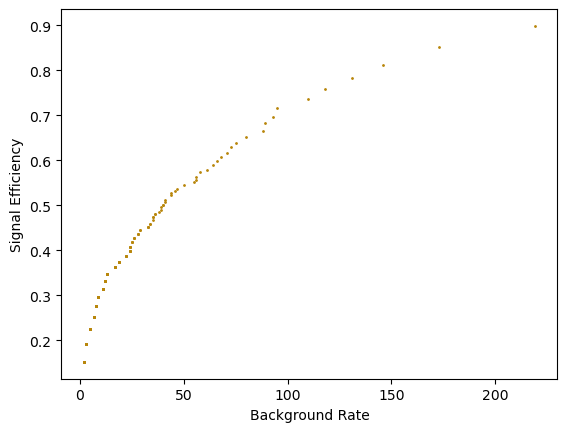

In [45]:
plt.scatter(b_rates_gnn, s_effs_gnn, s = 1, color = 'darkgoldenrod')
#plt.scatter(b_rates_bdt, s_effs_bdt, s = 1, color = 'midnightblue')
plt.xlabel("Background Rate")
plt.ylabel("Signal Efficiency")
#each point indicates a different discriminator threshold. This is similar to a ROC curve I guess! Lets us probe the zero area though
comb_arr = np.column_stack((np.array(b_rates_gnn), np.array(s_effs_gnn)))
comb_arr_rel = comb_arr[comb_arr[:,1] > 0.25]
comb_arr_rel = comb_arr_rel[comb_arr_rel[:,1] < 0.28]

In [46]:
comb_arr[comb_arr[:,0] == 5]

array([[5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.        , 0.22409785],
       [5.

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
from torch.utils.data import ConcatDataset
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool
from torch_geometric.nn import GCNConv as gcn
from torch_geometric.nn import EdgeConv 
from torch_geometric.nn import DynamicEdgeConv 

In [50]:
sys.path.append("modules")
import architectures as arch

In [53]:
model_preloaded_dynamic = arch.GNN_v3_dynamic(
        in_channels=4,
        hc1=10, hc2=20, hc3=40, hc4=50,
        fc1=25, fc2=12, fc3=6,
        k1=33,  k2=25,  k3=17, k4=9,
        out_channels=2,
    )
trained_model_state_dict_dynamic = torch.load('/standard/ldmxuva/gnn_files/run_output/dynamic_run_extended_best_model.pt', weights_only = True, map_location=torch.device('cpu'))
model_preloaded_dynamic.load_state_dict(trained_model_state_dict_dynamic)


<All keys matched successfully>

In [54]:
total_params = sum(p.numel() for p in model_preloaded_dynamic.parameters())
print(f"Total Parameters: {total_params:,}")

Total Parameters: 25,249
